In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# Устанавливаем seed для воспроизводимости
torch.manual_seed(912)
np.random.seed(912)

# 1. Генерация датасета
def generate_data(n_samples=500, noise=0.0):
    X = np.random.randn(n_samples, 2) * 1.5
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(np.float32) * 2 - 1
    return X, y

# Параметры датасета
X, y = generate_data(n_samples=500)

/tmp/ipykernel_545/2311984559.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


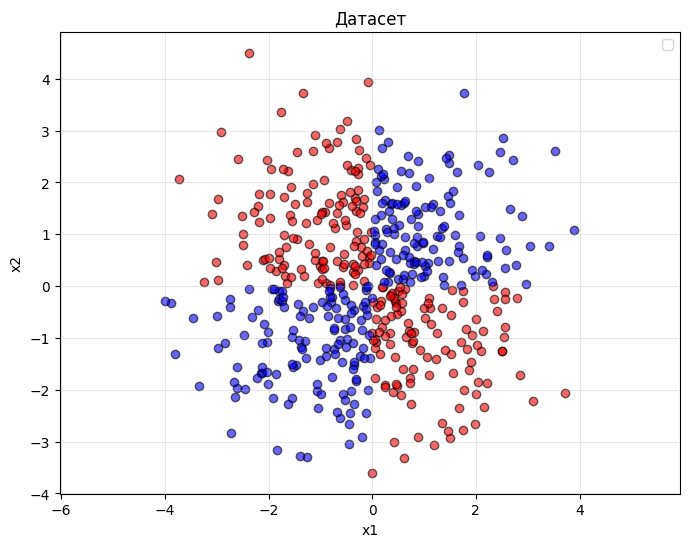

In [35]:
# Визуализация данных
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 1, 0], X[y == 1, 1],
            color='red', alpha=0.6, edgecolors='k')
plt.scatter(X[y == -1, 0], X[y == -1, 1],
            color='blue', alpha=0.6, edgecolors='k')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Датасет')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')  # равный масштаб осей для наглядности
plt.show()

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

In [37]:
# Преобразование в тензоры PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

TensorDataset и DataLoader — это стандартные инструменты PyTorch для организации загрузки данных при обучении моделей.

In [38]:
# Создаем DataLoader для батчей (batchSize=10)
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False)

Создадим аналогичную архитектуру
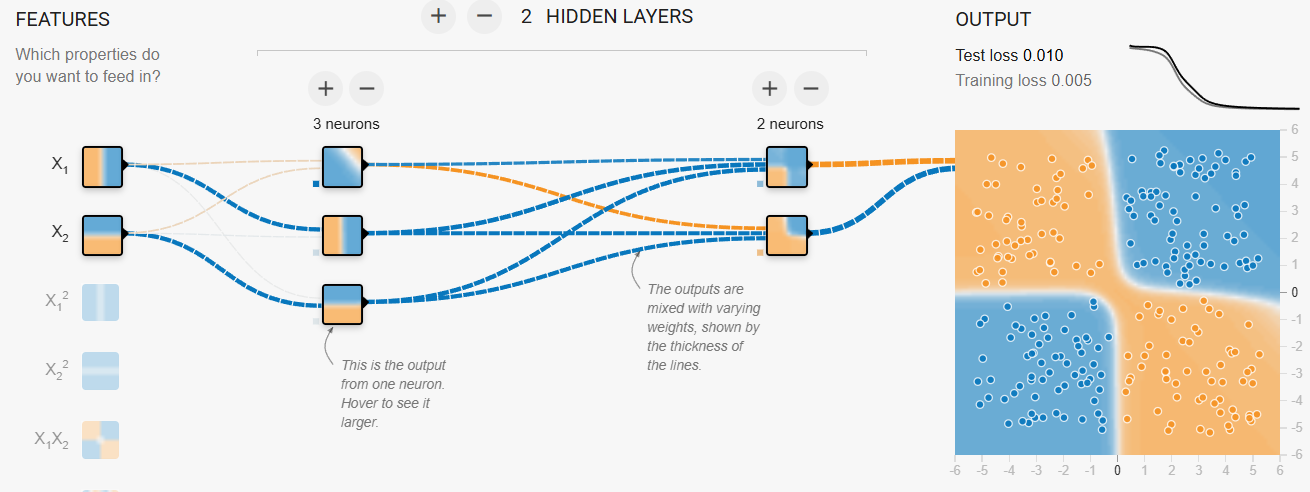

In [39]:
# 2. Определение архитектуры нейронной сети
# Входной слой равен 2 (input_size)
# Первый скрытый слой: линейный слой с 3 нейронами (nn.Linear(2, 3)), после которого применяется гиперболический тангенс (Tanh).
# Второй скрытый слой: линейный слой с 2 нейронами (nn.Linear(3, 2)), затем Tanh.
# Выходной слой: линейный слой с 1 нейроном (nn.Linear(2, 1)), после него также Tanh.

class Network(nn.Module):
    def __init__(self, input_size=2, output_size=1):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 3)
        self.tanh1 = nn.Tanh()
        self.layer2 = nn.Linear(3, 2)
        self.tanh2 = nn.Tanh()
        self.layer3 = nn.Linear(2, output_size)
        self.tanh3 = nn.Tanh()

    def forward(self, x):
        out = self.layer1(x)
        out = self.tanh1(out)
        out = self.layer2(out)
        out = self.tanh2(out)
        out = self.layer3(out)
        out = self.tanh3(out)
        return out

# Создаем модель
model = Network(input_size=2, output_size=1)

In [40]:
# 3. Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.03, weight_decay=0.001)

In [41]:
# 4. Обучение модели
num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    # Training
    epoch_train_loss = 0

    # Перебираем все батчи из обучающего набора
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()     # Обнуляем результаты обратного прохождения прошлого шага
        outputs = model(batch_X)  # Прямой проход: вычисляем предсказания для текуших данных
        loss = criterion(outputs, batch_y)  # Вычисляем функцию потерь (MSE) между предсказаниями и истинными метками
        loss.backward()           # Обратное прохождение: вычисляем, в какую сторону и на сколько нужно менять веса модели
        optimizer.step()          # Обновляем веса модели

        # Накопление потерь: сумма потерь по всем элементам
        epoch_train_loss += loss.item() * len(batch_X)

    # Вычисляем среднюю потерю на обучающем наборе за эпоху
    avg_train_loss = epoch_train_loss / len(train_dataset)
    train_losses.append(avg_train_loss)

    # Логирование каждые 10 эпох
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}')

Epoch [10/50], Train Loss: 0.9447
Epoch [20/50], Train Loss: 0.8631
Epoch [30/50], Train Loss: 0.5804
Epoch [40/50], Train Loss: 0.3154
Epoch [50/50], Train Loss: 0.1899


In [42]:
test_loss = 0
with torch.no_grad():
    test_loss = 0
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)           # Прямой проход на тестовом батче
        loss = criterion(outputs, batch_y) # Вычисление потерь
        test_loss += loss.item() * len(batch_X)

    test_loss = test_loss / len(test_dataset)
test_loss

0.14284227505326272

In [43]:
# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')


Final Results:
Test loss: 0.14284227505326272
Training loss: 0.190


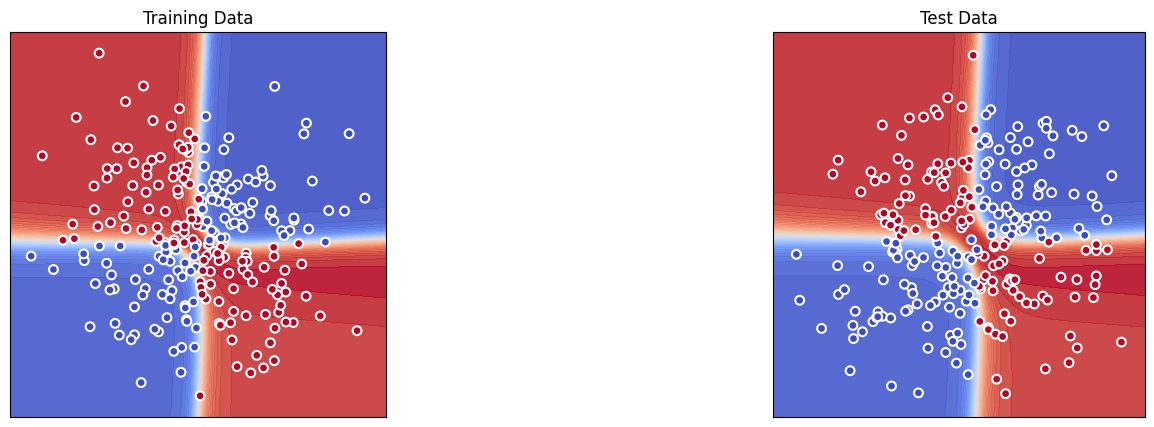

In [44]:
# 5. Визуализация результатов
def plot_decision_boundary(model, X, y, ax, cmap='coolwarm', alpha=0.9, point_size=40):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        Z = model(grid_tensor).numpy()
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=50, cmap=cmap, alpha=alpha)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap,
                         edgecolors='white', linewidth=1.5, s=point_size)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_aspect('equal')
    ax.grid(False)

    ax.set_xticks([])
    ax.set_yticks([])

    return scatter

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Граница решения для тренировочных данных
plot_decision_boundary(model, X_train, y_train, axes[0], cmap='coolwarm')
axes[0].set_title('Training Data')

# Граница решения для тестовых данных
plot_decision_boundary(model, X_test, y_test, axes[1], cmap='coolwarm')
axes[1].set_title('Test Data')

# Вывод финальных значений
print(f"\nFinal Results:")
print(f"Test loss: {test_loss}")
print(f"Training loss: {train_losses[-1]:.3f}")